# Day 1 — 멀티모달 임베딩과 CLIP 유사도


## 1. 실습 목표

- 사전학습된 CLIP 모델을 불러온다.
- 이미지와 텍스트를 모델 입력 형식으로 전처리한다.
- 이미지·텍스트 임베딩을 추출하고 코사인 유사도를 계산한다.
- 결과를 숫자와 그래프로 확인한다.

**주의:** 최초 실행 시 모델 가중치를 다운로드하므로 인터넷 연결이 필요하다. GPU가 없어도 작은 예제는 CPU에서 실행할 수 있지만, 처리 속도는 느릴 수 있다.

In [ ]:
# 필요한 라이브러리를 설치한다.
# 이미 설치되어 있다면 이 셀은 생략해도 된다.
# !uv add -q torch torchvision transformers pillow numpy matplotlib

In [1]:
# 이미지 처리, 수치 계산, 시각화, PyTorch, Hugging Face 모델 클래스를 불러온다.
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from transformers import CLIPModel, CLIPProcessor

# GPU가 사용 가능하면 GPU를 선택하고, 그렇지 않으면 CPU를 사용한다.
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print("실행 장치:", device)

# CLIP의 공개 사전학습 체크포인트를 지정한다.
# 이 모델은 이미지와 텍스트를 같은 임베딩 공간에서 비교하도록 학습되어 있다.
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"

# Processor는 이미지 크기 조정·정규화와 텍스트 토큰화를 처리한다.
processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)

# Model은 학습된 가중치를 포함한다.
model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(device)

# 이번 수업은 모델을 새로 학습하는 것이 아니라 추론하는 과정이므로 eval 모드로 전환한다.
model.eval()

print("CLIP 모델 로드 완료")

c:\lab\llm-workspace\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


실행 장치: cpu


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 8470.59it/s]

CLIP 모델 로드 완료


## 2. 실습용 이미지 준비

아래 코드는 인터넷에 연결된 환경에서 공개 이미지 하나를 불러오는 예시이다. 외부 이미지 다운로드가 막힌 환경에서는 `Image.open("내_이미지_경로.jpg")`로 본인 이미지 파일을 불러온다.

모델 입력은 RGB 이미지여야 하므로 `convert("RGB")`를 사용한다.

In [4]:

import platform

# 1. OS별 한글 폰트 설정
if platform.system() == "Darwin":  # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":  # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:  # Linux (Colab, Ubuntu 등)
    plt.rcParams["font.family"] = "NanumGothic"

# 2. 마이너스(-) 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

이미지를 불러왔다.


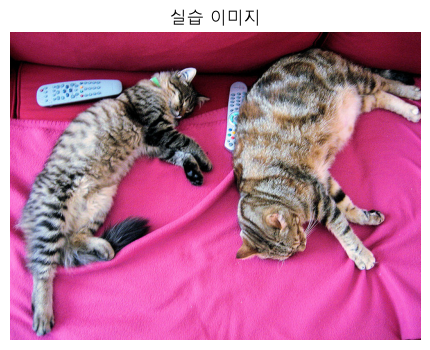

In [5]:
from urllib.request import urlopen

# 공개 예시 이미지 URL이다. 네트워크 정책에 따라 다운로드가 차단될 수 있다.
IMAGE_URL = "http://images.cocodataset.org/val2017/000000039769.jpg"

try:
    with urlopen(IMAGE_URL, timeout=20) as response:
        image = Image.open(response).convert("RGB")
    print("이미지를 불러왔다.")
except Exception as exc:
    # 네트워크 실패 시 로컬 이미지 경로를 지정하도록 오류를 명확히 안내한다.
    raise RuntimeError(
        "예시 이미지를 다운로드하지 못했다. 인터넷 연결을 확인하거나 "
        "IMAGE_URL 대신 로컬 이미지 파일을 Image.open()으로 불러오도록 수정한다."
    ) from exc

plt.figure(figsize=(6, 4))
plt.imshow(image)
plt.axis("off")
plt.title("실습 이미지")
plt.show()

## 3. 이미지와 텍스트를 모델 입력으로 변환

CLIP은 원본 이미지나 문장을 그대로 비교하지 않는다. Processor가 이미지 픽셀값을 모델이 기대하는 텐서로 바꾸고, 텍스트는 토큰 ID로 변환한다.

In [6]:
# 비교할 문장 후보를 준비한다.
texts = [
    "A photo of a cat.",
    "A photo of two cats sitting on a couch.",
    "A photo of a dog.",
    "A photo of a car.",
]

# images와 text를 함께 전달하면 두 입력을 각각 모델 입력 텐서로 전처리한다.
# return_tensors="pt"는 결과를 PyTorch 텐서로 반환하라는 뜻이다.
inputs = processor(
    text=texts,
    images=image,
    return_tensors="pt",
    padding=True
)

# 모델과 입력 텐서가 같은 장치(CPU 또는 GPU)에 있어야 한다.
inputs = {key: value.to(device) for key, value in inputs.items()}

# 각 입력 항목의 크기를 출력해 이미지와 텍스트가 어떤 형태로 표현되는지 확인한다.
for key, value in inputs.items():
    print(key, tuple(value.shape))

input_ids (4, 12)
attention_mask (4, 12)
pixel_values (1, 3, 224, 224)


## 4. 이미지 임베딩과 텍스트 임베딩 추출

임베딩은 이미지나 텍스트의 특징을 숫자 벡터로 표현한 것이다. 같은 의미를 가진 이미지와 문장이 비슷한 방향의 벡터를 갖도록 학습하는 것이 CLIP의 핵심 아이디어다.

In [7]:
import torch
import torch.nn.functional as F

# 추론 단계에서는 기울기를 계산할 필요가 없으므로 torch.no_grad()를 사용한다.
with torch.no_grad():
    # 이미지 인코더가 이미지의 특징 벡터를 만든다.
    image_outputs = model.get_image_features(
        pixel_values=inputs["pixel_values"]
    )

    # 텍스트 인코더가 각 문장의 특징 벡터를 만든다.
    text_outputs = model.get_text_features(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
    )


# 1. BaseModelOutputWithPooling 객체에서 안전하게 PyTorch Tensor만 추출하는 함수
def extract_tensor(output):
    # 이미 PyTorch Tensor인 경우 그대로 반환
    if isinstance(output, torch.Tensor):
        return output
    # image_embeds / text_embeds 속성이 있는 경우
    if hasattr(output, "image_embeds") and output.image_embeds is not None:
        return output.image_embeds
    if hasattr(output, "text_embeds") and output.text_embeds is not None:
        return output.text_embeds
    # pooler_output 속성이 있는 경우 (BaseModelOutputWithPooling 기본 속성)
    if hasattr(output, "pooler_output") and output.pooler_output is not None:
        return output.pooler_output
    # 튜플/객체의 첫 번째 요소 추출 ([0])
    return output[0]

# 텐서 추출 실행
image_features = extract_tensor(image_outputs)
text_features = extract_tensor(text_outputs)

# 3. 코사인 유사도를 쉽게 계산할 수 있도록 각 벡터의 길이를 1로 정규화한다.
image_features = F.normalize(image_features, p=2, dim=-1)
text_features = F.normalize(text_features, p=2, dim=-1)

print("이미지 임베딩 크기:", tuple(image_features.shape))
print("텍스트 임베딩 크기:", tuple(text_features.shape))

이미지 임베딩 크기: (1, 512)
텍스트 임베딩 크기: (4, 512)


## 5. 코사인 유사도 계산

벡터 길이가 1로 정규화된 경우 두 벡터의 내적은 코사인 유사도와 같다. 값이 높을수록 두 벡터의 방향이 비슷하다는 뜻이다. 단, 이 값 자체가 정답일 확률은 아니다.

1위 | 유사도=0.2863 | 문장=A photo of two cats sitting on a couch.
2위 | 유사도=0.2487 | 문장=A photo of a cat.
3위 | 유사도=0.1927 | 문장=A photo of a dog.
4위 | 유사도=0.1886 | 문장=A photo of a car.


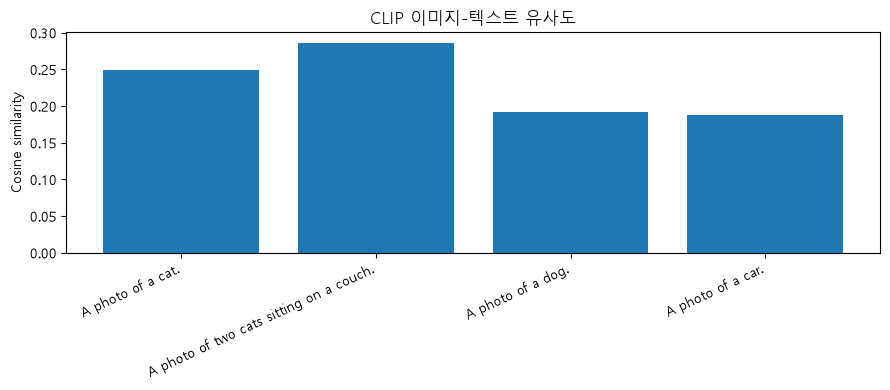

In [8]:
# 이미지 1개와 텍스트 후보 여러 개 사이의 유사도를 계산한다.
# image_features: [이미지 수, 임베딩 차원]
# text_features.T: [임베딩 차원, 텍스트 수]
similarities = image_features @ text_features.T

# 첫 번째 이미지에 대한 각 텍스트 유사도를 1차원 배열로 가져온다.
scores = similarities[0].detach().cpu().numpy()

# 높은 점수부터 정렬하여 결과를 확인한다.
ranked_indices = np.argsort(scores)[::-1]
for rank, idx in enumerate(ranked_indices, start=1):
    print(f"{rank}위 | 유사도={scores[idx]:.4f} | 문장={texts[idx]}")

# 막대그래프로 유사도를 시각화한다.
plt.figure(figsize=(9, 4))
plt.bar(range(len(texts)), scores)
plt.xticks(range(len(texts)), texts, rotation=25, ha="right")
plt.ylabel("Cosine similarity")
plt.title("CLIP 이미지-텍스트 유사도")
plt.tight_layout()
plt.show()

## 6. 학습 확인 질문

1. 이미지와 텍스트는 왜 각각 인코더를 통과하는가?
2. 임베딩은 원본 이미지나 문장과 무엇이 다른가?
3. 코사인 유사도가 높다는 사실만으로 문장이 사실이라고 단정할 수 있는가?
4. 후보 문장을 바꾸면 순위가 바뀔 수 있는 이유는 무엇인가?


<details>
<summary>정답 보기</summary>


| 질문 | 답안 |
| --- | --- |
| 이미지와 텍스트는 왜 각각 인코더를 통과하는가? | 이미지(2D/3D 픽셀 배열)와 텍스트(1D 문자열)는 데이터 구조가 완전히 다르므로, 각 매체에 특화된 연산 기법(ViT/CNN 및 Transformer)으로 연관성을 계산할 수 있는 공통 차원의 특징 벡터로 변환하기 위함이다. |
| 임베딩은 원본 이미지나 문장과 무엇이 다른가? | 원본 데이터는 사람이 읽고 보는 가공되지 않은 형태인 반면, 임베딩은 의미와 맥락 정보를 수치화하여 고차원 공간 상의 위치(고정 길이 고차원 수치 벡터)로 압축한 표현 방식이다. |
| 코사인 유사도가 높다는 사실만으로 문장이 사실이라고 단정할 수 있는가? | 단정할 수 없다. 코사인 유사도는 이미지의 시각적 형태와 문장의 시맨틱(의미적/묘사적) 유사성만 평가할 뿐, 문장 속 진위 여부나 논리적 사실 관계를 판단하지는 않는다. |
| 후보 문장을 바꾸면 순위가 바뀔 수 있는 이유는 무엇인가? | CLIP 등의 대조 학습 모델은 후보군 전체에 대해 상대적 유사도 확률(Softmax)을 계산하므로, 비교 대상(지배적 키워드나 반대 개념)이 달라지면 상대적 확률 분배와 최종 순위가 변동된다. |


</details>


### 실습 과제

- 후보 문장에 색상, 개수, 행동을 다르게 표현한 문장을 추가한다.
- 문장 표현을 바꿀 때 유사도 순위가 어떻게 달라지는지 기록한다.
- 결과가 실제 이미지와 일치하는지 사람이 확인하고, 모델의 한계를 3가지 작성한다.

<details>
<summary>정답 보기</summary>

예를 들어 실제 이미지가 **흰색 강아지 한 마리가 앉아 있는 사진**이라고 가정하고 실습할 수 있다.

### 1. 후보 문장 작성

색상, 개수, 행동을 하나씩 다르게 하여 비교한다.

```python
texts = [
    # 기본 표현
    "A photo of a dog.",

    # 색상 비교
    "A photo of a white dog.",
    "A photo of a black dog.",

    # 개수 비교
    "A photo of one dog.",
    "A photo of two dogs.",

    # 행동 비교
    "A white dog sitting.",
    "A white dog running.",
    "A white dog sleeping."
]
```

CLIP으로 유사도를 계산한다.

```python
# 이미지와 후보 문장을 CLIP 입력 형태로 변환한다.
inputs = processor(
    images=image,
    text=texts,
    return_tensors="pt",
    padding=True
)

# 입력 데이터를 모델과 동일한 장치로 이동한다.
inputs = {
    key: value.to(device)
    for key, value in inputs.items()
}

# 추론이므로 기울기를 계산하지 않는다.
with torch.no_grad():
    outputs = model(**inputs)

# 이미지와 각 텍스트 사이의 점수를 가져온다.
logits = outputs.logits_per_image[0]

# 후보 문장 안에서 상대적인 점수로 변환한다.
probs = logits.softmax(dim=0)

# 점수가 높은 순서대로 정렬한다.
results = sorted(
    zip(texts, probs.tolist()),
    key=lambda x: x[1],
    reverse=True
)

# 결과 출력
for rank, (text, score) in enumerate(results, start=1):
    print(f"{rank}위 | {score:.4f} | {text}")
```

### 2. 결과 기록

실제 점수는 사용하는 이미지와 모델에 따라 달라진다. 따라서 아래 표의 점수는 **작성 예시**이며, 실습에서는 직접 실행한 결과를 기록한다.

| 순위 | 후보 문장 | 관찰 내용 |
|---:|---|---|
| 1 | `A photo of a white dog.` | 실제 이미지의 색상과 일치 |
| 2 | `A white dog sitting.` | 색상과 행동이 모두 일치 |
| 3 | `A photo of one dog.` | 강아지 개수와 일치 |
| 4 | `A photo of a dog.` | 객체는 일치하지만 구체적 정보가 없음 |
| 5 | `A white dog running.` | 색상은 맞지만 행동이 다름 |
| 6 | `A photo of a black dog.` | 객체는 맞지만 색상이 다름 |
| 7 | `A white dog sleeping.` | 색상은 맞지만 행동이 다름 |
| 8 | `A photo of two dogs.` | 객체는 맞지만 개수가 다름 |

**주의할 점:** `softmax`를 사용하면 모든 후보가 서로 경쟁한다. 따라서 후보 문장을 추가하거나 제거하면 기존 문장의 softmax 점수도 달라질 수 있다.

---

## 3. 결과 분석 모범 답안

실제 이미지가 **흰색 강아지 한 마리가 앉아 있는 사진**이라면 다음 문장이 이미지 내용을 가장 구체적으로 표현한다.

> `A white dog sitting.`

하지만 CLIP에서 반드시 이 문장이 1위가 되는 것은 아니다.

CLIP은 이미지에서 `색상 → 개수 → 행동`을 각각 독립적으로 판별한 다음 정답을 결정하는 전통적인 분류기가 아니다. 이미지 전체와 문장 전체를 각각 임베딩 벡터로 변환한 후 **의미적 유사도**를 비교한다.

즉,

```text
실제 이미지
   │
   ▼
Image Encoder
   │
   ▼
이미지 임베딩 ─────────┐
                       │ 유사도 비교
텍스트 임베딩 ─────────┘
   ▲
   │
Text Encoder
   ▲
   │
"A white dog sitting."
```

따라서 사람이 보기에 더 정확한 문장이 항상 가장 높은 유사도를 얻는 것은 아니다.

---

# 4. 모델의 한계 3가지

### 한계 1. 세부 속성 구분이 정확하지 않을 수 있다

CLIP은 객체 자체는 잘 인식하면서도 색상과 같은 세부 속성을 정확하게 구별하지 못할 수 있다.

예를 들어 실제 강아지가 흰색인데도

```text
A photo of a white dog.
A photo of a black dog.
```

두 문장의 점수 차이가 예상보다 작을 수 있다.

### 한계 2. 개수 판단이 부정확할 수 있다

CLIP은 다음과 같은 수량 차이를 항상 정확하게 구별하는 것은 아니다.

```text
A photo of one dog.
A photo of two dogs.
```

객체가 `dog`라는 의미가 두 문장 모두에 강하게 포함되어 있기 때문에 개수보다 객체 자체의 의미가 유사도에 더 크게 반영될 수 있다.

### 한계 3. 행동이나 관계를 잘못 판단할 수 있다

다음 문장은 모두 `white dog`라는 공통 의미를 가지고 있다.

```text
A white dog sitting.
A white dog running.
A white dog sleeping.
```

실제로는 앉아 있는 사진이어도 `running` 또는 `sleeping` 문장이 예상보다 높은 점수를 얻을 수 있다.

---

## 과제 최종 작성 예시

> 후보 문장에 강아지의 색상, 개수, 행동을 다르게 표현하여 CLIP의 이미지-텍스트 유사도를 비교하였다. 실제 이미지는 흰색 강아지 한 마리가 앉아 있는 사진이다. 후보 문장의 표현을 변경하자 유사도와 순위가 달라지는 것을 확인할 수 있었다. 또한 실제 이미지와 정확하게 일치하는 문장이 반드시 가장 높은 점수를 얻는 것은 아니었다. 이는 CLIP이 색상, 개수, 행동을 각각 독립적으로 판별하는 모델이 아니라 이미지와 텍스트를 임베딩 공간에 표현하여 전체적인 의미적 유사도를 비교하기 때문이다. 실험을 통해 CLIP은 세부 속성 구분, 정확한 객체 수 판단, 행동 및 관계 이해에서 한계가 있을 수 있음을 확인하였다.

이 과제의 핵심은 **“1위가 무엇인가”보다 “문장을 어떻게 바꾸었을 때 순위가 왜 달라졌는가”를 분석하는 것**이다.

</details>